In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [2]:
import numpy as np
import pandas as pd
import sys
import os
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [3]:
import seaborn as sns

- iris 데이터
1. sepal_length : 꽃받침 길이
2. sepal_width : 꽃받침 넓이
3. petal_length : 꽃잎 길이
4. petal_width : 꽃잎 넓이
5. species 

In [8]:
# 문자변수의 원핫인코딩 방법 1
# 문자 -> (라벨인코더) 숫자 -> (투카테고리컬) 원핫인코딩
iris = sns.load_dataset('iris')
iris.iloc[::25]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica
125,7.2,3.2,6.0,1.8,virginica


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(iris['species'])
# iris['y'] = le.transform(iris['species'])
iris['y'] = le.fit_transform(iris['species'])
# iris.iloc[::25]
to_categorical(iris.y)[::25] # to_categorical의 결과는 mubpy배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [14]:
# 문자 변수 원핫 인코딩 방법 2
iris = sns.load_dataset('iris')
# iris.iloc[::25]
pd.get_dummies(iris.species).values # pd.get_dummies 결과는 데이터프레임
pd.get_dummies(iris.species).to_numpy()[::25]

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]], dtype=uint8)

In [22]:
# 1. 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
# iris.info() 결측치 있으면 결측치 처리
iris['species'].value_counts()  # 타겟변수의 분포 확인. 서로 균등하게 만드는게 가장 좋다
# 독립변수와 타겟변수 분리
iris_X = iris.iloc[:, :-1].to_numpy()
iris_y = iris.iloc[:, -1]
iris_Y = pd.get_dummies(iris_y).values
# iris_Y
X_train, X_test, Y_train, Y_test = train_test_split(iris_X, iris_Y,
                                                   #test_size=0.2, # 테스트비율
                                                   train_size=0.8, # 훈련셋 비율
                                                   stratify=iris_Y, # 층화추출
                                                   random_state=7 # 랜덤시드값
                                                   )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(150, 4) (150, 3)
(120, 4) (120, 3)
(30, 4) (30, 3)


In [27]:
iris_Y.argmax(axis=1)
np.argmax(iris_Y, axis=1)  # numpy는 밸류카운츠 함수가 없음
print(pd.Series(np.argmax(iris_Y, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_train, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_test, axis=1)).value_counts())

0    50
1    50
2    50
dtype: int64
0    40
2    40
1    40
dtype: int64
0    10
2    10
1    10
dtype: int64


In [46]:
# 2. 모델구성
model = Sequential()
model.add(Dense(units=64, input_dim=4, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax')) # 출력층
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_17 (Dense)            (None, 64)                320       
                                                                 
 dense_18 (Dense)            (None, 128)               8320      
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_19 (Dense)            (None, 50)                6450      
                                                                 
 dropout_5 (Dropout)         (None, 50)                0         
                                                                 
 dense_20 (Dense)            (None, 30)                1530      
                                                                 
 dense_21 (Dense)            (None, 3)                

In [47]:
# 모델 학습 구성
model.compile(loss = 'categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 학습하기(epoch마다 val_accuracy값이 좋아지고 잇으면 model자동저장 콜백 추가)
    # 모델 자동저장 폴더 
save_folder = './model_10/'
if not save_folder:
    os.mkdir(save_folder)
file = save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'
# 저장할 콜백 객체
save_point = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy',
                            mode='max', 
                            save_best_only=True, # False = 매번저장
                            verbose=1)
earlystopping = EarlyStopping(patience=40) # 모니터 기본값은 val_losss

hist = model.fit(X_train, Y_train,
              batch_size= 150,
              epochs=200, 
              validation_split=0.2,
              verbose=1,
              callbacks=[save_point, earlystopping])    

Epoch 1/200
1/1 [==============================] - ETA: 0s - loss: 1.0763 - accuracy: 0.3021
Epoch 1: val_accuracy improved from -inf to 0.70833, saving model to ./model_10\iris-001-val0.7083.h5
1/1 [==============================] - 1s 608ms/step - loss: 1.0763 - accuracy: 0.3021 - val_loss: 0.9640 - val_accuracy: 0.7083
Epoch 2/200
1/1 [==============================] - ETA: 0s - loss: 1.0169 - accuracy: 0.4167
Epoch 2: val_accuracy did not improve from 0.70833
1/1 [==============================] - 0s 35ms/step - loss: 1.0169 - accuracy: 0.4167 - val_loss: 0.9118 - val_accuracy: 0.7083
Epoch 3/200
1/1 [==============================] - ETA: 0s - loss: 0.9474 - accuracy: 0.5833
Epoch 3: val_accuracy improved from 0.70833 to 0.79167, saving model to ./model_10\iris-003-val0.7917.h5
1/1 [==============================] - 0s 59ms/step - loss: 0.9474 - accuracy: 0.5833 - val_loss: 0.8634 - val_accuracy: 0.7917
Epoch 4/200
1/1 [==============================] - ETA: 0s - loss: 0.8969 - ac

1/1 [==============================] - ETA: 0s - loss: 0.3919 - accuracy: 0.8646
Epoch 30: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 34ms/step - loss: 0.3919 - accuracy: 0.8646 - val_loss: 0.3236 - val_accuracy: 0.9167
Epoch 31/200
1/1 [==============================] - ETA: 0s - loss: 0.3856 - accuracy: 0.8333
Epoch 31: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 34ms/step - loss: 0.3856 - accuracy: 0.8333 - val_loss: 0.3172 - val_accuracy: 0.9167
Epoch 32/200
1/1 [==============================] - ETA: 0s - loss: 0.3635 - accuracy: 0.8646
Epoch 32: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 34ms/step - loss: 0.3635 - accuracy: 0.8646 - val_loss: 0.3128 - val_accuracy: 0.9167
Epoch 33/200
1/1 [==============================] - ETA: 0s - loss: 0.3448 - accuracy: 0.8958
Epoch 33: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 34m

Epoch 60/200
1/1 [==============================] - ETA: 0s - loss: 0.1830 - accuracy: 0.9479
Epoch 60: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 33ms/step - loss: 0.1830 - accuracy: 0.9479 - val_loss: 0.1828 - val_accuracy: 0.9167
Epoch 61/200
1/1 [==============================] - ETA: 0s - loss: 0.1787 - accuracy: 0.9583
Epoch 61: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 35ms/step - loss: 0.1787 - accuracy: 0.9583 - val_loss: 0.1893 - val_accuracy: 0.9167
Epoch 62/200
1/1 [==============================] - ETA: 0s - loss: 0.1886 - accuracy: 0.9271
Epoch 62: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 34ms/step - loss: 0.1886 - accuracy: 0.9271 - val_loss: 0.2127 - val_accuracy: 0.9167
Epoch 63/200
1/1 [==============================] - ETA: 0s - loss: 0.1506 - accuracy: 0.9479
Epoch 63: val_accuracy did not improve from 0.91667
1/1 [===========================

Epoch 90/200
1/1 [==============================] - ETA: 0s - loss: 0.0793 - accuracy: 0.9792
Epoch 90: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 33ms/step - loss: 0.0793 - accuracy: 0.9792 - val_loss: 0.1872 - val_accuracy: 0.9167
Epoch 91/200
1/1 [==============================] - ETA: 0s - loss: 0.1455 - accuracy: 0.9167
Epoch 91: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 33ms/step - loss: 0.1455 - accuracy: 0.9167 - val_loss: 0.1805 - val_accuracy: 0.9167
Epoch 92/200
1/1 [==============================] - ETA: 0s - loss: 0.1108 - accuracy: 0.9479
Epoch 92: val_accuracy did not improve from 0.91667
1/1 [==============================] - 0s 32ms/step - loss: 0.1108 - accuracy: 0.9479 - val_loss: 0.1867 - val_accuracy: 0.9167
Epoch 93/200
1/1 [==============================] - ETA: 0s - loss: 0.0795 - accuracy: 0.9792
Epoch 93: val_accuracy did not improve from 0.91667
1/1 [===========================

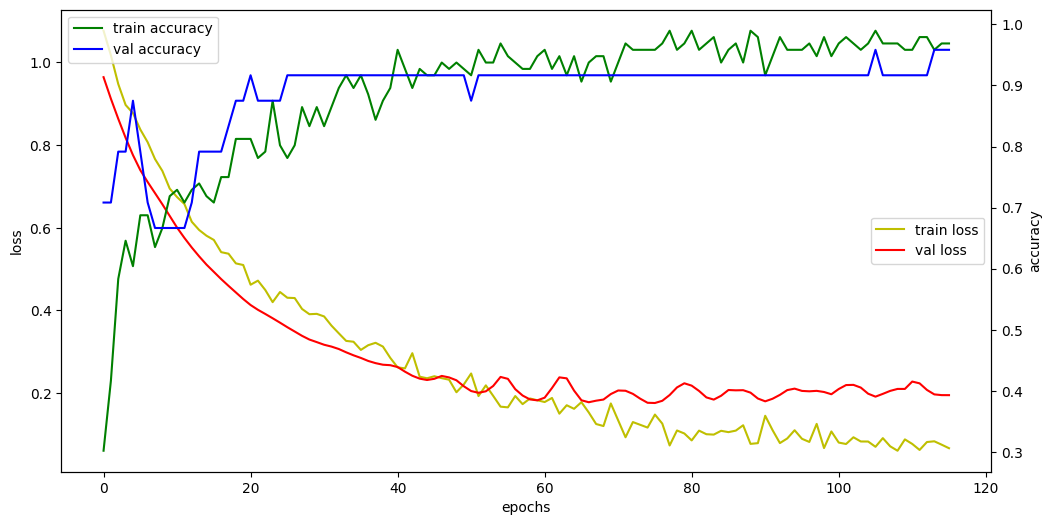

In [48]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()



In [52]:
# 평가하기

loss, acc = model.evaluate(X_test, Y_test, batch_size=100, verbose=0)
print('loss :', loss)
print('accuracy :', acc)

# 교차표
Y_hat = model.predict(X_test).argmax(axis=1)
crosstab = pd.crosstab(Y_test.argmax(axis=1), Y_hat,
                      rownames=['실제값'], colnames=['예측값'])
display(crosstab)

loss : 0.024776523932814598
accuracy : 1.0
1/1 [==============================] - 0s 31ms/step


예측값,0,1,2
실제값,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [60]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
# 학습완료된 모델 평가
loss, acc = model.evaluate(X_test, Y_test, batch_size=100, verbose=0)
print('loss :', loss)
print('accuracy :', acc)

real = np.argmax(Y_test, axis=1)
pred = np.argmax(model.predict(X_test), axis = 1)
recall = recall_score(real, pred, average='weighted')
precision = precision_score(real, pred, average='weighted')
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model accuracy :', acc)
print('model recall :', recall)
print('model precision :', precision)
print('model f1_score :', f1)
print('=============================='*2)

crosstab = pd.crosstab(Y_test.argmax(axis=1), pred,
                      rownames=['실제값'], colnames=['예측값'])
display(crosstab)

# 자동 저장된 iris-106-val0.9583.h5 모델도 같이 평가
# model2 = load_model('model_10/iris-106-val0.9583.h5')
# model2.summary()

# loss, acc = model2.evaluate(X_test, Y_test, batch_size=100, verbose=0)
# print('loss :', loss)
# print('accuracy :', acc)

# pred = np.argmax(model2.predict(X_test), axis = 1)
# recall = recall_score(real, pred, average='weighted')
# precision = precision_score(real, pred, average='weighted')
# precision = precision_score(real, pred, average='weighted')
# f1 = f1_score(real, pred, average='weighted')
# print('model2 accuracy :', acc)
# print('model2 recall :', recall)
# print('model2 precision :', precision)
# print('model2 f1_score :', f1)

loss : 0.024776523932814598
accuracy : 1.0
1/1 [==============================] - 0s 18ms/step
model accuracy : 1.0
model recall : 1.0
model precision : 1.0
model f1_score : 1.0


예측값,0,1,2
실제값,,,
0,10,0,0
1,0,10,0
2,0,0,10
